Cats vs Dogs CNN (ReLU)

In [1]:
# CELL 1 — Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# CELL 2 — Load Cats vs Dogs dataset
# Uses the Hugging Face "cats_vs_dogs" dataset via torchvision-compatible wrapper
# pip install datasets pillow
from datasets import load_dataset

hf_dataset = load_dataset("microsoft/cats_vs_dogs", split="train")
print(hf_dataset)

c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\chari\.cache\huggingface\hub\datasets--microsoft--cats_vs_dogs. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an

Dataset({
    features: ['image', 'labels'],
    num_rows: 23410
})


In [3]:
# CELL 3 — Wrap in a PyTorch Dataset with transforms
from torch.utils.data import Dataset
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class CatsDogsDataset(Dataset):
    def __init__(self, hf_ds, transform=None):
        self.ds = hf_ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item["image"].convert("RGB")
        label = item["labels"]  # 0 = cat, 1 = dog
        if self.transform:
            img = self.transform(img)
        return img, label

full_dataset = CatsDogsDataset(hf_dataset, transform=transform)

# Use a manageable subset for quick training
subset_size = 5000
subset, _ = random_split(full_dataset, [subset_size, len(full_dataset) - subset_size])

train_size = int(0.8 * subset_size)
test_size = subset_size - train_size
train_dataset, test_dataset = random_split(subset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train samples: 4000 | Test samples: 1000


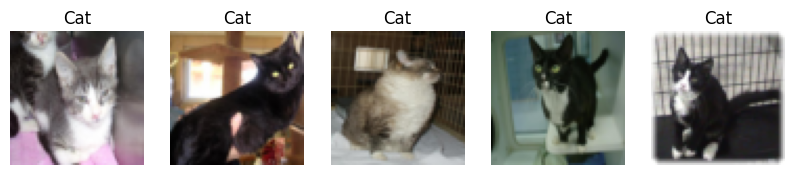

In [4]:
# CELL 4 — Visualize a few samples
def unnormalize(img):
    return img * 0.5 + 0.5

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    img, label = train_dataset[i]
    axes[i].imshow(unnormalize(img).permute(1, 2, 0))
    axes[i].set_title("Dog" if label == 1 else "Cat")
    axes[i].axis("off")
plt.show()

In [5]:
# CELL 5 — Model definition
class CatsDogsCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # raw logits — cat vs dog
        )

    def forward(self, x):
        x = self.conv_stack(x)
        return self.classifier(x)

model = CatsDogsCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

CatsDogsCNN(
  (conv_stack): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [6]:
# CELL 6 — Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

Epoch 1/5 — Loss: 0.6527 | Train Acc: 60.48%
Epoch 2/5 — Loss: 0.5889 | Train Acc: 68.60%
Epoch 3/5 — Loss: 0.5279 | Train Acc: 74.15%
Epoch 4/5 — Loss: 0.4858 | Train Acc: 76.80%
Epoch 5/5 — Loss: 0.4334 | Train Acc: 79.47%


In [7]:
# CELL 7 — Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 75.00%


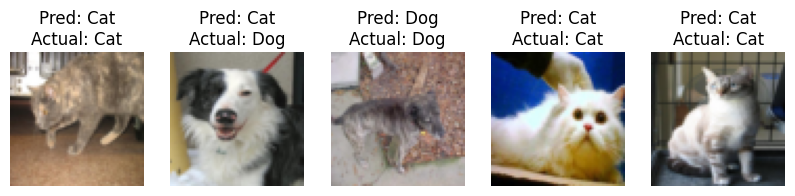

In [8]:
# CELL 8 — Visualize predictions
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images[:5])
    preds = torch.argmax(logits, dim=1)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(unnormalize(images[i].cpu()).permute(1, 2, 0))
    pred_label = "Dog" if preds[i].item() == 1 else "Cat"
    actual_label = "Dog" if labels[i].item() == 1 else "Cat"
    axes[i].set_title(f"Pred: {pred_label}\nActual: {actual_label}")
    axes[i].axis("off")
plt.show()